# Продажи в магазине — прогнозирование временных рядов

https://www.kaggle.com/competitions/store-sales-time-series-forecasting/overview

## Импорт библиотек

In [2]:
!pip install catboost


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import make_scorer

from sklearn.model_selection import RandomizedSearchCV

In [4]:
warnings.filterwarnings('ignore')

## Загрузка данных

In [5]:
train_df = pd.read_csv('../data/train.csv', parse_dates=['date']).drop(columns="id")
test_df = pd.read_csv("../data/test.csv", parse_dates=["date"])
stores_df = pd.read_csv("../data/stores.csv")
oil_df = pd.read_csv("../data/oil.csv", parse_dates=["date"])
transactions_df = pd.read_csv("../data/transactions.csv", parse_dates=["date"])
holidays_df = pd.read_csv("../data/holidays_events.csv", parse_dates=["date"])
sample_submission = pd.read_csv("../data/sample_submission.csv")

In [6]:
train_df.shape

(3000888, 5)

## Описание данных

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 5 columns):
 #   Column       Dtype         
---  ------       -----         
 0   date         datetime64[ns]
 1   store_nbr    int64         
 2   family       object        
 3   sales        float64       
 4   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 114.5+ MB


| Поле          | Тип            | Описание                                                                                       |
| ------------- | -------------- | ---------------------------------------------------------------------------------------------- |
| `date`        | datetime64[ns] | Дата продажи. Период: с 2013-01-01 по 2017-08-15.                                              |
| `store_nbr`   | int64          | Номер магазина (идентификатор).                                                                |
| `family`      | object         | Категория товара (например, GROCERY I, AUTOMOTIVE и т. д.).                                    |
| `sales`       | float64        | Количество проданных единиц товара за день. Это целевая переменная (то, что мы предсказываем). |
| `onpromotion` | int64          | Количество товаров этой категории, находящихся в акции в конкретный день и магазине.           |


In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           28512 non-null  int64         
 1   date         28512 non-null  datetime64[ns]
 2   store_nbr    28512 non-null  int64         
 3   family       28512 non-null  object        
 4   onpromotion  28512 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.1+ MB


| Поле          | Тип            | Описание                                       |
| ------------- | -------------- | ---------------------------------------------- |
| `id`          | int64          | Уникальный идентификатор строки (для сабмита). |
| `date`        | datetime64[ns] | Дата (период: с 2017-08-16 по 2017-08-31).     |
| `store_nbr`   | int64          | Номер магазина.                                |
| `family`      | object         | Категория товара.                              |
| `onpromotion` | int64          | Количество акционных товаров.                  |


In [9]:
stores_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


| Поле        | Тип    | Описание                                     |
| ----------- | ------ | -------------------------------------------- |
| `store_nbr` | int64  | Идентификатор магазина.                      |
| `city`      | object | Город, где расположен магазин.               |
| `state`     | object | Провинция/регион.                            |
| `type`      | object | Тип магазина (A, B, C, D и т. д.).           |
| `cluster`   | int64  | Группа схожих магазинов по поведению продаж. |


In [10]:
oil_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1218 non-null   datetime64[ns]
 1   dcoilwtico  1175 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.2 KB


| Поле         | Тип            | Описание                                     |
| ------------ | -------------- | -------------------------------------------- |
| `date`       | datetime64[ns] | Дата.                                        |
| `dcoilwtico` | float64        | Цена на нефть WTI в долларах США за баррель. |


In [11]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          83488 non-null  datetime64[ns]
 1   store_nbr     83488 non-null  int64         
 2   transactions  83488 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.9 MB


| Поле           | Тип            | Описание                        |
| -------------- | -------------- | ------------------------------- |
| `date`         | datetime64[ns] | Дата.                           |
| `store_nbr`    | int64          | Идентификатор магазина.         |
| `transactions` | int64          | Количество покупок в этот день. |


In [12]:
holidays_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         350 non-null    datetime64[ns]
 1   type         350 non-null    object        
 2   locale       350 non-null    object        
 3   locale_name  350 non-null    object        
 4   description  350 non-null    object        
 5   transferred  350 non-null    bool          
dtypes: bool(1), datetime64[ns](1), object(4)
memory usage: 14.1+ KB


| Поле          | Тип            | Описание                                                              |
| ------------- | -------------- | --------------------------------------------------------------------- |
| `date`        | datetime64[ns] | Дата праздника.                                                       |
| `type`        | object         | Тип события: Holiday, Transfer, Bridge, Work Day, Event и т. д.       |
| `locale`      | object         | Уровень, на котором действует праздник: National, Regional или Local. |
| `locale_name` | object         | Название региона или города, к которому относится праздник.           |
| `description` | object         | Описание события.                                                     |
| `transferred` | bool           | Флаг, показывающий, был ли праздник перенесён на другую дату.         |


## Первичная обработка

### Объединение с тестовым

In [13]:
train_df['id'] = np.nan
test_df['sales'] = np.nan

In [14]:
train_df['is_train'] = 1
test_df['is_train'] = 0

In [15]:
train_df = pd.concat([train_df, test_df], ignore_index=True)

### Обработка цен на нефть

In [16]:
train_df["date"].min(), train_df["date"].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-31 00:00:00'))

In [17]:
data_range = pd.date_range(start=train_df["date"].min(), end=train_df["date"].max(), freq="d")

In [18]:
data_range_df = pd.DataFrame(data_range, columns=['date'])
data_range_df['dcoilwtico'] = np.nan

In [19]:
data_range_df.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,NaN
2,2013-01-03,NaN
3,2013-01-04,NaN
4,2013-01-05,NaN


In [20]:
oil_df = data_range_df.merge(oil_df, on='date', how="left")
oil_df = oil_df.drop(columns=['dcoilwtico_x'])
oil_df = oil_df.rename(columns={'dcoilwtico_y': 'dcoilwtico'})

In [21]:
oil_df.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-05,NaN


#### Заполнение пропусков

In [22]:
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].interpolate(method="linear").ffill().bfill()

In [23]:
oil_df.head()

,date,dcoilwtico
0,2013-01-01,93.140000
1,2013-01-02,93.140000
2,2013-01-03,92.970000
3,2013-01-04,93.120000
4,2013-01-05,93.146667


### Праздники

In [24]:
holidays_df.shape

(350, 6)

In [25]:
holidays_df.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


#### Убираем перенесённые праздники

In [26]:
holidays_df = holidays_df[holidays_df['transferred'] == False]
holidays_df = holidays_df.drop(columns=['transferred', "description"])

In [27]:
holidays_df = holidays_df[~holidays_df['type'].isin(['Bridge', 'Work Day'])]

In [28]:
holidays_df.head()

,date,type,locale,locale_name
0,2012-03-02,Holiday,Local,Manta
1,2012-04-01,Holiday,Regional,Cotopaxi
2,2012-04-12,Holiday,Local,Cuenca
3,2012-04-14,Holiday,Local,Libertad
4,2012-04-21,Holiday,Local,Riobamba


In [29]:
holidays_df.shape

(328, 4)

### Объединение таблиц

In [30]:
df = train_df.copy()

In [31]:
df["is_payday"] = ((df["date"].dt.day == 15) | (df["date"].dt.is_month_end)).astype(int)
df['is_payday_next'] = df['is_payday'].shift(1, fill_value=1)

In [32]:
df['post_earthquake'] = ((df['date'] >= '2016-04-16') & (df['date'] <= '2016-05-15')).astype(int)

In [33]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [34]:
df['day_week'] = df['date'].dt.day_of_week

In [35]:
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

In [36]:
df.head()

,date,store_nbr,family,sales,onpromotion,id,is_train,is_payday,is_payday_next,post_earthquake,year,month,day,day_week,week_of_year
0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,1,0,1,0,2013,1,1,1,1
1,2013-01-01,1,BABY CARE,0.0,0,NaN,1,0,0,0,2013,1,1,1,1
2,2013-01-01,1,BEAUTY,0.0,0,NaN,1,0,0,0,2013,1,1,1,1
3,2013-01-01,1,BEVERAGES,0.0,0,NaN,1,0,0,0,2013,1,1,1,1
4,2013-01-01,1,BOOKS,0.0,0,NaN,1,0,0,0,2013,1,1,1,1


#### Объединение с магазинами и ценами на нефть

In [37]:
df = (df
      .merge(stores_df, on='store_nbr', how='left')
      .merge(oil_df, on='date', how='left')
      )


In [38]:
df.head()

,date,store_nbr,family,sales,onpromotion,id,is_train,is_payday,is_payday_next,post_earthquake,year,month,day,day_week,week_of_year,city,state,type,cluster,dcoilwtico
0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,1,0,1,0,2013,1,1,1,1,Quito,Pichincha,D,13,93.14
1,2013-01-01,1,BABY CARE,0.0,0,NaN,1,0,0,0,2013,1,1,1,1,Quito,Pichincha,D,13,93.14
2,2013-01-01,1,BEAUTY,0.0,0,NaN,1,0,0,0,2013,1,1,1,1,Quito,Pichincha,D,13,93.14
3,2013-01-01,1,BEVERAGES,0.0,0,NaN,1,0,0,0,2013,1,1,1,1,Quito,Pichincha,D,13,93.14
4,2013-01-01,1,BOOKS,0.0,0,NaN,1,0,0,0,2013,1,1,1,1,Quito,Pichincha,D,13,93.14


#### Объединение с праздниками

In [39]:
holidays_df.head()

,date,type,locale,locale_name
0,2012-03-02,Holiday,Local,Manta
1,2012-04-01,Holiday,Regional,Cotopaxi
2,2012-04-12,Holiday,Local,Cuenca
3,2012-04-14,Holiday,Local,Libertad
4,2012-04-21,Holiday,Local,Riobamba


In [40]:
national = holidays_df[holidays_df['locale'] == 'National']
regional = holidays_df[holidays_df['locale'] == 'Regional']
local = holidays_df[holidays_df['locale'] == 'Local']

In [41]:
national = national[['date', 'type']]
df = df.merge(national, on='date', how='left', suffixes=('', '_national'))
df["holiday_nat"] = df["type_national"].notna().astype(int)
df = df.drop(columns=['type_national'])

In [42]:
regional = regional[['date', 'type', 'locale_name']]
df = df.merge(regional, left_on=['date', "state"], right_on=['date', 'locale_name'], how='left',
              suffixes=('', '_regional'))
df['holiday_reg'] = df['type_regional'].notna().astype(int)
df = df.drop(columns=['type_regional', "locale_name"])

In [43]:
local = local[['date', 'type', 'locale_name']]
df = df.merge(local, left_on=['date', "city"], right_on=['date', 'locale_name'], how='left', suffixes=('', '_local'))
df['holiday_loc'] = df['type_local'].notna().astype(int)
df = df.drop(columns=['type_local', "locale_name"])

In [44]:
df['is_holiday'] = df[['holiday_nat', 'holiday_reg', 'holiday_loc']].any(axis=1).astype(int)
df = df.drop(columns=['holiday_nat', 'holiday_reg', 'holiday_loc'])

### Обработка основной таблицы

In [45]:
df.head()

,date,store_nbr,family,sales,onpromotion,id,is_train,is_payday,is_payday_next,post_earthquake,...,month,day,day_week,week_of_year,city,state,type,cluster,dcoilwtico,is_holiday
0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,1,0,1,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1
1,2013-01-01,1,BABY CARE,0.0,0,NaN,1,0,0,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1
2,2013-01-01,1,BEAUTY,0.0,0,NaN,1,0,0,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1
3,2013-01-01,1,BEVERAGES,0.0,0,NaN,1,0,0,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1
4,2013-01-01,1,BOOKS,0.0,0,NaN,1,0,0,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1


In [46]:
df = df.rename(columns={
    'type': 'store_type',
    'dcoilwtico': 'oil_price'})

#### Приведение типов

In [47]:
object_columns = df.select_dtypes(include=['object']).columns
for col in object_columns:
    df[col] = df[col].astype('string')

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035010 entries, 0 to 3035009
Data columns (total 21 columns):
 #   Column           Dtype         
---  ------           -----         
 0   date             datetime64[ns]
 1   store_nbr        int64         
 2   family           string        
 3   sales            float64       
 4   onpromotion      int64         
 5   id               float64       
 6   is_train         int64         
 7   is_payday        int64         
 8   is_payday_next   int64         
 9   post_earthquake  int64         
 10  year             int32         
 11  month            int32         
 12  day              int32         
 13  day_week         int32         
 14  week_of_year     int64         
 15  city             string        
 16  state            string        
 17  store_type       string        
 18  cluster          int64         
 19  oil_price        float64       
 20  is_holiday       int64         
dtypes: datetime64[ns](1), float64(3

| №  | Название столбца    | Тип данных     | Описание                                                                                                                                                   |
| -- | ------------------- | -------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 0  | **date**            | datetime64[ns] | Дата продажи товара в магазине.                                                                                                                            |
| 1  | **store_nbr**       | int64          | Уникальный номер магазина.                                                                                                                                 |
| 2  | **family**          | string         | Категория товара                                                                                             |
| 3  | **sales**           | float64        | Объём продаж товара (в тысячах единиц). **Целевая переменная**; в тестовой выборке отсутствует (`NaN`).                                                    |
| 4  | **onpromotion**     | int64          | Количество единиц товара, участвовавших в акции в указанный день.                                                                                          |
| 5  | **id**              | float64        | Служебный признак |
| 6  | **is_train**        | int64          | Служебный признак: `1` — строка относится к обучающей выборке, `0` — к тестовой.                                                                           |
| 7  | **is_payday**       | int64          | Признак дня зарплаты: `1` — 15-е число или последний день месяца, `0` — остальные дни.                                                                     |
| 8  | **is_payday_next**  | int64          | Признак дня после зарплаты: `1` — предыдущий день был зарплатным, `0` — иначе.                                                                             |
| 9  | **post_earthquake** | int64          | Признак периода после землетрясения 16 апреля 2016 года: `1` — период влияния, `0` — иначе.                                                                |
| 10 | **year**            | int32          | Год продажи.                                                                                                                                               |
| 11 | **month**           | int32          | Месяц продажи.                                                                                                                                             |
| 12 | **day**             | int32          | День месяца.                                                                                                                                               |
| 13 | **day_week**        | int32          | День недели (0 — понедельник, 6 — воскресенье).                                                                                                            |
| 14 | **week_of_year**    | int64          | Номер недели в году.                                                                                                                                       |
| 15 | **city**            | string         | Город, в котором расположен магазин.                                                                                                                       |
| 16 | **state**           | string         | Регион (штат), к которому относится город.                                                                                                                 |
| 17 | **store_type**      | string         | Тип магазина (*A*, *B*, *C*, *D*).                                                                                                                         |
| 18 | **cluster**         | int64          | Кластер магазина по совокупности характеристик.                                                                                                            |
| 19 | **oil_price**       | float64        | Цена нефти (*dcoilwtico*) на соответствующую дату.                                                                                                         |
| 20 | **is_holiday**      | int64          | Признак праздничного дня: `1` — праздник (национальный, региональный или локальный), `0` — обычный день.                                                   |


#### Проверка на пропуски

In [49]:
df.isnull().sum()

date                     0
store_nbr                0
family                   0
sales                28512
onpromotion              0
id                 3006498
is_train                 0
is_payday                0
is_payday_next           0
post_earthquake          0
year                     0
month                    0
day                      0
day_week                 0
week_of_year             0
city                     0
state                    0
store_type               0
cluster                  0
oil_price                0
is_holiday               0
dtype: int64

In [50]:
df.isna().sum()

date                     0
store_nbr                0
family                   0
sales                28512
onpromotion              0
id                 3006498
is_train                 0
is_payday                0
is_payday_next           0
post_earthquake          0
year                     0
month                    0
day                      0
day_week                 0
week_of_year             0
city                     0
state                    0
store_type               0
cluster                  0
oil_price                0
is_holiday               0
dtype: int64

Пропуски в id - это весь тренировочный набор
Пропуски в sales - это весь тестовый набор

#### Проверка на дупликаты

In [51]:
df.shape

(3035010, 21)

In [52]:
df.duplicated().sum()

np.int64(5610)

In [53]:
df = df.drop_duplicates().reset_index(drop=True)

In [54]:
df.duplicated().sum()

np.int64(0)

In [55]:
df.shape

(3029400, 21)

## Удаление выбросов

In [56]:
df.shape

(3029400, 21)

In [57]:
# iso = IsolationForest(contamination='auto', random_state=42)

# mask = iso.fit_predict(df[['sales']])
# outliers_mask = mask == -1

# n_outliers = outliers_mask.sum()
# share = n_outliers / len(df)

# n_outliers, share

In [58]:
# for c in [0.005, 0.01, 0.02]:
#     iso = IsolationForest(contamination=c, random_state=42)
#     iso.fit(df[['sales']])
#     print(c, (iso.predict(df[['sales']]) == -1).mean())


In [59]:
# no_nan_mask = df_lagged[num_features].notna().all(axis=1)
# clean_data = df_lagged[num_features][no_nan_mask]
#
# iso_forest = IsolationForest(contamination='auto', random_state=42)
# iso_forest.fit(clean_data)
# outliers = iso_forest.predict(clean_data)
#
# clean_index = clean_data[outliers != -1].index
# df_lagged_filter = df_lagged.loc[clean_index]
#
# df_lagged = pd.concat([df_lagged_filter, df_lagged[~no_nan_mask]], ignore_index=True)
# df_lagged.reset_index(drop=True, inplace=True)
# df_lagged.shape

In [60]:
# # Группируем по city и store_type и считаем медиану sales
# group_medians = df.groupby(['city', 'store_type'])['sales'].median()
# group_medians

In [61]:
# global_median = df['sales'].median()
#
# # Функция для замены выбросов
# def replace_outlier(row, outliers):
#     if outliers[row.name] == -1:  # если выброс
#         # пытаемся взять медиану группы
#         val = group_medians.get((row['city'], row['store_type']), np.nan)
#         # если медиана группы NaN, подставляем глобальную медиану
#         if np.isnan(val):
#             val = global_median
#         return val
#     else:
#         return row['sales']

In [62]:
# global_median = df['sales'].median()
#
# # Функция для замены выбросов
# def replace_outlier(row, outliers):
#     if outliers[row.name] == -1:  # если выброс
#         val = global_median
#         return val
#     else:
#         return row['sales']

In [63]:
# # 1. Берём только тренировочные данные
# train_mask = df['is_train'] == 1
# df_train = df.loc[train_mask].copy()
#
# # 2. Берём только столбец sales для поиска выбросов
# sales_data = df_train[['sales']]
#
# # 3. Обучаем Isolation Forest
# iso = IsolationForest(
#     contamination='auto',  # автоопределение выбросов
#     random_state=42,
#     n_jobs=-1
# )
# iso.fit(sales_data)
#
# # 4. Определяем выбросы
# outliers = iso.predict(sales_data)  # -1 = выброс, 1 = нормальные
#
# # 5. Заменяем выбросы
# df_train['sales'] = df_train.apply(
#     replace_outlier,
#     axis=1,
#     args=(outliers, )
# )
#
# # 6. Объединяем с тестовыми данными без изменений
# df_clean = pd.concat([df_train, df.loc[~train_mask]], axis=0).sort_index()
# df_clean.reset_index(drop=True, inplace=True)
#
# df_clean.shape

In [64]:
# 1. Берём только тренировочные данные
train_mask = df['is_train'] == 1
df_train = df.loc[train_mask].copy()

# 2. Берём только столбец sales для поиска выбросов
sales_data = df_train[['sales']]

# 3. Isolation Forest
iso = IsolationForest(
    contamination='auto',  # автоопределение доли выбросов
    random_state=42,
    n_jobs=-1
)
iso.fit(sales_data)

# 4. Предсказание выбросов
outliers = iso.predict(sales_data)  # -1 = выброс

# 5. Индексы НЕ выбросов
clean_idx = sales_data.index[outliers != -1]

# 6. Оставляем только нормальные строки train
df_train_filtered = df_train.loc[clean_idx]

# 7. Возвращаем test без изменений
df_clean = pd.concat(
    [df_train_filtered, df.loc[~train_mask]],
    axis=0
).sort_index()

df_clean.reset_index(drop=True, inplace=True)
print(df_clean.shape)


(2504267, 21)


In [65]:
df = df_clean.copy()

## Добавление лагов

In [66]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2504267 entries, 0 to 2504266
Data columns (total 21 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   date             2504267 non-null  datetime64[ns]
 1   store_nbr        2504267 non-null  int64         
 2   family           2504267 non-null  string        
 3   sales            2475755 non-null  float64       
 4   onpromotion      2504267 non-null  int64         
 5   id               28512 non-null    float64       
 6   is_train         2504267 non-null  int64         
 7   is_payday        2504267 non-null  int64         
 8   is_payday_next   2504267 non-null  int64         
 9   post_earthquake  2504267 non-null  int64         
 10  year             2504267 non-null  int32         
 11  month            2504267 non-null  int32         
 12  day              2504267 non-null  int32         
 13  day_week         2504267 non-null  int32         
 14  we

### Обработка категорий датасета

In [67]:
categorical_cols = ['store_nbr', 'family', 'city', 'state', 'store_type', 'cluster']
for col in categorical_cols:
    df[col] = df[col].astype('category')


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2504267 entries, 0 to 2504266
Data columns (total 21 columns):
 #   Column           Dtype         
---  ------           -----         
 0   date             datetime64[ns]
 1   store_nbr        category      
 2   family           category      
 3   sales            float64       
 4   onpromotion      int64         
 5   id               float64       
 6   is_train         int64         
 7   is_payday        int64         
 8   is_payday_next   int64         
 9   post_earthquake  int64         
 10  year             int32         
 11  month            int32         
 12  day              int32         
 13  day_week         int32         
 14  week_of_year     int64         
 15  city             category      
 16  state            category      
 17  store_type       category      
 18  cluster          category      
 19  oil_price        float64       
 20  is_holiday       int64         
dtypes: category(6), datetime64[ns](

| №  | Название столбца    | Тип данных     | Описание                                                                                                                                                  |
| -- | ------------------- | -------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 0  | **date**            | datetime64[ns] | Дата продажи товара в магазине.                                                                                                                           |
| 1  | **store_nbr**       | category       | Уникальный номер магазина (категориальный признак).                                                                                                       |
| 2  | **family**          | category       | Категория товара (*AUTOMOTIVE*, *BABY CARE* и др.).                                                                                                       |
| 3  | **sales**           | float64        | Объём продаж товара (в тысячах единиц). **Целевая переменная**; в тестовой выборке отсутствует (`NaN`).                                                   |
| 4  | **onpromotion**     | int64          | Количество единиц товара, участвовавших в акции в указанный день.                                                                                         |
| 5  | **id**              | float64        | Идентификатор строки тестовой выборки. Для строк обучающей выборки принимает значение `NaN`. Используется при формировании файла отправки (`submission`). |
| 6  | **is_train**        | int64          | Служебный признак: `1` — строка относится к обучающей выборке, `0` — к тестовой.                                                                          |
| 7  | **is_payday**       | int64          | Признак дня выплаты заработной платы: `1` — 15-е число или последний день месяца, `0` — остальные дни.                                                    |
| 8  | **is_payday_next**  | int64          | Признак дня после зарплаты: `1` — предыдущий день был зарплатным, `0` — иначе.                                                                            |
| 9  | **post_earthquake** | int64          | Признак периода после землетрясения 16 апреля 2016 года: `1` — период влияния, `0` — иначе.                                                               |
| 10 | **year**            | int32          | Год продажи.                                                                                                                                              |
| 11 | **month**           | int32          | Месяц продажи (1–12). Порядковый календарный признак.                                                                                                     |
| 12 | **day**             | int32          | День месяца.                                                                                                                                              |
| 13 | **day_week**        | int32          | День недели (0 — понедельник, 6 — воскресенье). Порядковый признак.                                                                                       |
| 14 | **week_of_year**    | int64          | Номер недели в году.                                                                                                                                      |
| 15 | **city**            | category       | Город, в котором расположен магазин.                                                                                                                      |
| 16 | **state**           | category       | Регион (штат), к которому относится город.                                                                                                                |
| 17 | **store_type**      | category       | Тип магазина (*A*, *B*, *C*, *D*).                                                                                                                        |
| 18 | **cluster**         | category       | Кластер магазина по совокупности характеристик.                                                                                                           |
| 19 | **oil_price**       | float64        | Цена нефти (*dcoilwtico*) на соответствующую дату.                                                                                                        |
| 20 | **is_holiday**      | int64          | Признак праздничного дня: `1` — праздник (национальный, региональный или локальный), `0` — обычный день.                                                  |


### Добавление лагов

In [69]:
df_lagged = df.copy()

In [70]:
df_lagged.head()

,date,store_nbr,family,sales,onpromotion,id,is_train,is_payday,is_payday_next,post_earthquake,...,month,day,day_week,week_of_year,city,state,store_type,cluster,oil_price,is_holiday
0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,1,0,1,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1
1,2013-01-01,1,BABY CARE,0.0,0,NaN,1,0,0,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1
2,2013-01-01,1,BEAUTY,0.0,0,NaN,1,0,0,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1
3,2013-01-01,1,BEVERAGES,0.0,0,NaN,1,0,0,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1
4,2013-01-01,1,BOOKS,0.0,0,NaN,1,0,0,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1


In [71]:
# Параметры
LONG_LAGS_START = 16  # начало длинных лагов
LONG_LAGS_END = 30  # конец длинных лагов
ROLL_WINDOW = 28  # окно для rolling mean и std
ONPROMO_LAGS = [1, 7, 14, 16, 28]
ONPROMO_ROLL = [7, 14, 16, 28]
OIL_PRICE_LAGS = [1, 7, 14, 16, 28]

# Сортировка и группировка
df_lagged = df_lagged.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
g = df_lagged.groupby(['store_nbr', 'family'], observed=False)

# Лаги продаж (16-30 дней)
for lag in range(LONG_LAGS_START, LONG_LAGS_END + 1):
    df_lagged[f'sales_lag_{lag}'] = g['sales'].shift(lag).clip(upper=50000)

# Rolling mean и std (28 дней)
df_lagged['sales_roll_mean_28'] = (
    g['sales']
    .shift(1)
    .rolling(window=ROLL_WINDOW, min_periods=1)
    .mean()
    .reset_index(drop=True)
)

df_lagged['sales_roll_std_28'] = (
    g['sales']
    .shift(1)
    .rolling(window=ROLL_WINDOW, min_periods=1)
    .std()
    .fillna(0)
    .reset_index(drop=True)
)

# Lag год назад (1y)
df_lagged['date_1y_ago'] = df_lagged['date'] - pd.DateOffset(years=1)
df_lagged = df_lagged.merge(
    df_lagged[['store_nbr', 'family', 'date', 'sales']],
    left_on=['store_nbr', 'family', 'date_1y_ago'],
    right_on=['store_nbr', 'family', 'date'],
    how='left',
    suffixes=('', '_lag_1y')
)
df_lagged.drop(columns=['date_1y_ago', 'date_lag_1y'], inplace=True, errors='ignore')

# Лаги onpromotion
for lag in ONPROMO_LAGS:
    df_lagged[f'onpromo_lag_{lag}'] = (
        g['onpromotion']
        .shift(lag)
        .fillna(0)   # просто fillna на Series группы, без apply
        .reset_index(drop=True)
    )
# Кол-во промо за последние дни
for w in ONPROMO_ROLL:
    df_lagged[f'promo_sum_last_{w}'] = (
        g['onpromotion']
        .shift(1)
        .rolling(window=w, min_periods=1)
        .sum()
        .fillna(0)
        .reset_index(drop=True)
    )

# Лаги для oil_price
for lag in OIL_PRICE_LAGS:
    df_lagged[f'oil_price_lag_{lag}'] = (
        g['oil_price']
        .shift(lag)
        .ffill()
        .reset_index(drop=True)
    )



### Работа с пропусками

In [72]:
df_lagged.isnull().sum()

date                        0
store_nbr                   0
family                      0
sales                   28512
onpromotion                 0
id                    2475755
is_train                    0
is_payday                   0
is_payday_next              0
post_earthquake             0
year                        0
month                       0
day                         0
day_week                    0
week_of_year                0
city                        0
state                       0
store_type                  0
cluster                     0
oil_price                   0
is_holiday                  0
sales_lag_16            28512
sales_lag_17            30294
sales_lag_18            32076
sales_lag_19            33858
sales_lag_20            35640
sales_lag_21            37422
sales_lag_22            39120
sales_lag_23            40798
sales_lag_24            42468
sales_lag_25            44136
sales_lag_26            45800
sales_lag_27            47460
sales_lag_

In [73]:
# # Заполняем пропуски
# df_lagged[df_lagged.select_dtypes(include=['number']).columns] = (
#     df_lagged.select_dtypes(include=['number']).fillna(0)
# )

In [74]:
for lag in ONPROMO_LAGS:
    df_lagged[f'onpromo_lag_{lag}'] = df_lagged[f'onpromo_lag_{lag}'].fillna(0)

for lag in OIL_PRICE_LAGS:
    df_lagged[f'oil_price_lag_{lag}'] = df_lagged[f'oil_price_lag_{lag}'].fillna(0)


In [75]:
df_lagged.isna().sum()

date                        0
store_nbr                   0
family                      0
sales                   28512
onpromotion                 0
id                    2475755
is_train                    0
is_payday                   0
is_payday_next              0
post_earthquake             0
year                        0
month                       0
day                         0
day_week                    0
week_of_year                0
city                        0
state                       0
store_type                  0
cluster                     0
oil_price                   0
is_holiday                  0
sales_lag_16            28512
sales_lag_17            30294
sales_lag_18            32076
sales_lag_19            33858
sales_lag_20            35640
sales_lag_21            37422
sales_lag_22            39120
sales_lag_23            40798
sales_lag_24            42468
sales_lag_25            44136
sales_lag_26            45800
sales_lag_27            47460
sales_lag_

In [76]:
df_lagged[df_lagged['is_train'] == 0].isna().sum()


date                      0
store_nbr                 0
family                    0
sales                 28512
onpromotion               0
id                        0
is_train                  0
is_payday                 0
is_payday_next            0
post_earthquake           0
year                      0
month                     0
day                       0
day_week                  0
week_of_year              0
city                      0
state                     0
store_type                0
cluster                   0
oil_price                 0
is_holiday                0
sales_lag_16           1282
sales_lag_17           1411
sales_lag_18           1541
sales_lag_19           1672
sales_lag_20           1806
sales_lag_21           1940
sales_lag_22           1990
sales_lag_23           2020
sales_lag_24           2042
sales_lag_25           2062
sales_lag_26           2079
sales_lag_27           2092
sales_lag_28           2107
sales_lag_29           2120
sales_lag_30        

In [77]:
LONG_LAGS = [f'sales_lag_{lag}' for lag in range(16, 31)]

df_lagged[LONG_LAGS] = df_lagged[LONG_LAGS].fillna(0)


In [78]:
df_lagged.isnull().sum()


date                        0
store_nbr                   0
family                      0
sales                   28512
onpromotion                 0
id                    2475755
is_train                    0
is_payday                   0
is_payday_next              0
post_earthquake             0
year                        0
month                       0
day                         0
day_week                    0
week_of_year                0
city                        0
state                       0
store_type                  0
cluster                     0
oil_price                   0
is_holiday                  0
sales_lag_16                0
sales_lag_17                0
sales_lag_18                0
sales_lag_19                0
sales_lag_20                0
sales_lag_21                0
sales_lag_22                0
sales_lag_23                0
sales_lag_24                0
sales_lag_25                0
sales_lag_26                0
sales_lag_27                0
sales_lag_

In [79]:
df_lagged.columns

Index(['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'id', 'is_train',
       'is_payday', 'is_payday_next', 'post_earthquake', 'year', 'month',
       'day', 'day_week', 'week_of_year', 'city', 'state', 'store_type',
       'cluster', 'oil_price', 'is_holiday', 'sales_lag_16', 'sales_lag_17',
       'sales_lag_18', 'sales_lag_19', 'sales_lag_20', 'sales_lag_21',
       'sales_lag_22', 'sales_lag_23', 'sales_lag_24', 'sales_lag_25',
       'sales_lag_26', 'sales_lag_27', 'sales_lag_28', 'sales_lag_29',
       'sales_lag_30', 'sales_roll_mean_28', 'sales_roll_std_28',
       'sales_lag_1y', 'onpromo_lag_1', 'onpromo_lag_7', 'onpromo_lag_14',
       'onpromo_lag_16', 'onpromo_lag_28', 'promo_sum_last_7',
       'promo_sum_last_14', 'promo_sum_last_16', 'promo_sum_last_28',
       'oil_price_lag_1', 'oil_price_lag_7', 'oil_price_lag_14',
       'oil_price_lag_16', 'oil_price_lag_28'],
      dtype='object')

In [80]:
df_lagged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2504267 entries, 0 to 2504266
Data columns (total 53 columns):
 #   Column              Dtype         
---  ------              -----         
 0   date                datetime64[ns]
 1   store_nbr           category      
 2   family              category      
 3   sales               float64       
 4   onpromotion         int64         
 5   id                  float64       
 6   is_train            int64         
 7   is_payday           int64         
 8   is_payday_next      int64         
 9   post_earthquake     int64         
 10  year                int32         
 11  month               int32         
 12  day                 int32         
 13  day_week            int32         
 14  week_of_year        int64         
 15  city                category      
 16  state               category      
 17  store_type          category      
 18  cluster             category      
 19  oil_price           float64       
 20  is

## Кодирование

In [81]:
num_features = df_lagged.select_dtypes(include=['float64', 'int32', 'int64']).columns.tolist()
cat_features = df_lagged.select_dtypes(include=['category']).columns.tolist()

In [82]:
num_features.remove('sales')

In [83]:
num_features

['onpromotion',
 'id',
 'is_train',
 'is_payday',
 'is_payday_next',
 'post_earthquake',
 'year',
 'month',
 'day',
 'day_week',
 'week_of_year',
 'oil_price',
 'is_holiday',
 'sales_lag_16',
 'sales_lag_17',
 'sales_lag_18',
 'sales_lag_19',
 'sales_lag_20',
 'sales_lag_21',
 'sales_lag_22',
 'sales_lag_23',
 'sales_lag_24',
 'sales_lag_25',
 'sales_lag_26',
 'sales_lag_27',
 'sales_lag_28',
 'sales_lag_29',
 'sales_lag_30',
 'sales_roll_mean_28',
 'sales_roll_std_28',
 'sales_lag_1y',
 'onpromo_lag_1',
 'onpromo_lag_7',
 'onpromo_lag_14',
 'onpromo_lag_16',
 'onpromo_lag_28',
 'promo_sum_last_7',
 'promo_sum_last_14',
 'promo_sum_last_16',
 'promo_sum_last_28',
 'oil_price_lag_1',
 'oil_price_lag_7',
 'oil_price_lag_14',
 'oil_price_lag_16',
 'oil_price_lag_28']

In [84]:
cat_features

['store_nbr', 'family', 'city', 'state', 'store_type', 'cluster']

In [85]:
for col in cat_features:
    n_unique = df_lagged[col].nunique()
    print(f"{col}: {n_unique} уникальных значений")

store_nbr: 54 уникальных значений
family: 33 уникальных значений
city: 22 уникальных значений
state: 16 уникальных значений
store_type: 5 уникальных значений
cluster: 17 уникальных значений


In [86]:
# Кодируем категориальные признаки
for col in cat_features:
    le = LabelEncoder()
    df_lagged[col] = le.fit_transform(df_lagged[col])

In [87]:
# # Признаки для Label Encoding
# label_cols = ['store_nbr', 'family']
#
# # Признаки для One-Hot Encoding
# one_hot_cols = ['city', 'state', 'store_type', 'cluster']

In [88]:
# df_encoded = pd.get_dummies(df_lagged, columns=one_hot_cols, drop_first=False)

In [89]:
# for col in label_cols:
#     le = LabelEncoder()
#     df_encoded[col] = le.fit_transform(df_encoded[col])

one_hot ухудшил точность, так что оставляем LabelEncoder

In [90]:
df_lagged.shape

(2504267, 53)

In [91]:
df_lagged.columns


Index(['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'id', 'is_train',
       'is_payday', 'is_payday_next', 'post_earthquake', 'year', 'month',
       'day', 'day_week', 'week_of_year', 'city', 'state', 'store_type',
       'cluster', 'oil_price', 'is_holiday', 'sales_lag_16', 'sales_lag_17',
       'sales_lag_18', 'sales_lag_19', 'sales_lag_20', 'sales_lag_21',
       'sales_lag_22', 'sales_lag_23', 'sales_lag_24', 'sales_lag_25',
       'sales_lag_26', 'sales_lag_27', 'sales_lag_28', 'sales_lag_29',
       'sales_lag_30', 'sales_roll_mean_28', 'sales_roll_std_28',
       'sales_lag_1y', 'onpromo_lag_1', 'onpromo_lag_7', 'onpromo_lag_14',
       'onpromo_lag_16', 'onpromo_lag_28', 'promo_sum_last_7',
       'promo_sum_last_14', 'promo_sum_last_16', 'promo_sum_last_28',
       'oil_price_lag_1', 'oil_price_lag_7', 'oil_price_lag_14',
       'oil_price_lag_16', 'oil_price_lag_28'],
      dtype='object')

## Разделение на тренировочную/тестовую

In [92]:
df_lagged.date.min(), df_lagged.date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-31 00:00:00'))

In [93]:
train_df = df_lagged[df_lagged['is_train'] == 1].copy()
test_df = df_lagged[df_lagged['is_train'] == 0].copy()

train_df.drop(columns=['is_train', 'id'], inplace=True)  # Удаляем лишние столбцы (Служебные)
test_df.drop(columns=['is_train', 'sales'], inplace=True)

In [94]:
train_df[LONG_LAGS].mean().mean()


np.float64(45.82841607647774)

In [95]:
test_df[LONG_LAGS].mean().mean()

np.float64(74.72390443597995)

In [96]:
train_df[LONG_LAGS].mean()
test_df[LONG_LAGS].mean()

sales_lag_16    74.547210
sales_lag_17    75.361918
sales_lag_18    76.080941
sales_lag_19    76.195888
sales_lag_20    75.632381
sales_lag_21    75.024311
sales_lag_22    74.909225
sales_lag_23    74.984929
sales_lag_24    75.330338
sales_lag_25    75.464168
sales_lag_26    74.770485
sales_lag_27    73.751500
sales_lag_28    73.284184
sales_lag_29    72.940089
sales_lag_30    72.580997
dtype: float64

In [97]:
train_df.date.min(), train_df.date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [98]:
test_df.date.min(), test_df.date.max()

(Timestamp('2017-08-16 00:00:00'), Timestamp('2017-08-31 00:00:00'))

In [99]:
# Пропуски после добаления лагов
train_df.isna().sum()

date                       0
store_nbr                  0
family                     0
sales                      0
onpromotion                0
is_payday                  0
is_payday_next             0
post_earthquake            0
year                       0
month                      0
day                        0
day_week                   0
week_of_year               0
city                       0
state                      0
store_type                 0
cluster                    0
oil_price                  0
is_holiday                 0
sales_lag_16               0
sales_lag_17               0
sales_lag_18               0
sales_lag_19               0
sales_lag_20               0
sales_lag_21               0
sales_lag_22               0
sales_lag_23               0
sales_lag_24               0
sales_lag_25               0
sales_lag_26               0
sales_lag_27               0
sales_lag_28               0
sales_lag_29               0
sales_lag_30               0
sales_roll_mea

### Удаляем пропуски в лагах в train_df

In [100]:
lag_cols = [c for c in train_df.columns if 'lag' in c
            or 'roll' in c
            or 'promo_sum' in c
            or 'diff' in c
            or 'pctchg' in c]

train_df[lag_cols] = train_df[lag_cols].fillna(0)

In [101]:
train_df.isna().sum()

date                  0
store_nbr             0
family                0
sales                 0
onpromotion           0
is_payday             0
is_payday_next        0
post_earthquake       0
year                  0
month                 0
day                   0
day_week              0
week_of_year          0
city                  0
state                 0
store_type            0
cluster               0
oil_price             0
is_holiday            0
sales_lag_16          0
sales_lag_17          0
sales_lag_18          0
sales_lag_19          0
sales_lag_20          0
sales_lag_21          0
sales_lag_22          0
sales_lag_23          0
sales_lag_24          0
sales_lag_25          0
sales_lag_26          0
sales_lag_27          0
sales_lag_28          0
sales_lag_29          0
sales_lag_30          0
sales_roll_mean_28    0
sales_roll_std_28     0
sales_lag_1y          0
onpromo_lag_1         0
onpromo_lag_7         0
onpromo_lag_14        0
onpromo_lag_16        0
onpromo_lag_28  

Теперь нет пропусков

### Разделение на тренировочную/валидацию

In [102]:
test_df.date.min(), test_df.date.max()

(Timestamp('2017-08-16 00:00:00'), Timestamp('2017-08-31 00:00:00'))

In [103]:
train_df.date.min(), train_df.date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [104]:
split_date = '2017-08-01'  # У валидации такой же размер как у тестовой

# Разделяем по дате
train_split_df = train_df[train_df['date'] < split_date].copy().drop(columns=['date'])
val_split_df = train_df[train_df['date'] >= split_date].copy().drop(columns=['date'])

In [105]:
test_df.drop(columns=['date'], inplace=True)

In [106]:
train_split_df.shape

(2454682, 50)

In [107]:
val_split_df.shape

(21073, 50)

In [108]:
test_df.shape

(28512, 50)

## Предсказательные модели

### Подготовка для обучения

In [109]:
# Целевой признак
target = 'sales'

# Признаки для модели (все кроме целевого и id, если он есть)
features = [c for c in train_split_df.columns if c != target]

X_train = train_split_df[features]
y_train = train_split_df[target]

X_val = val_split_df[features]
y_val = val_split_df[target]

In [110]:
test_features = [c for c in test_df.columns if c not in ['id', 'sales']]
X_test = test_df[test_features]

In [111]:
len(features)

49

In [112]:
len(test_features)

49

#### Функция оценки точности

In [113]:
def rmsle(y_true, y_pred):
    """
    Вычисляет RMSLE между истинными и предсказанными значениями.
    Отрицательные предсказания обрезаются в 0.
    """
    y_pred = np.maximum(0, y_pred)  # обрезаем отрицательные
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

### Random Forest Regressor

In [114]:
# # Параметры модели
# rf = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     random_state=42,
#     n_jobs=-1
# )
#
# # Обучаем на тренировочной выборке
# rf.fit(X_train, y_train)
#
# # Предсказания на валидации
# y_val_pred = rf.predict(X_val)
#
# # RMSLE
# rmsle_rf = rmsle(y_val, y_val_pred)
# print(f'RMSLE RF: {rmsle_rf:.5f}')

RMSLE RF: 0.47233

### XGBoost

In [115]:
# Параметры модели
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Обучение
xgb.fit(X_train, y_train)

# Предсказания на валидации
y_val_pred_xgb = xgb.predict(X_val)

# RMSLE
rmsle_xgb = rmsle(y_val, y_val_pred_xgb)
print(f'RMSLE XGB: {rmsle_xgb:.5f}')

RMSLE XGB: 0.45406


RMSLE XGB: 0.45406

               feature    importance
32  sales_roll_mean_28  3.389182e+07
22        sales_lag_21  7.881018e+06
29        sales_lag_28  1.297437e+06
33   sales_roll_std_28  6.421321e+05
9             day_week  4.415869e+05
7                month  3.596234e+05
8                  day  2.915936e+05
10        week_of_year  2.170945e+05
27        sales_lag_26  1.981923e+05
2          onpromotion  1.920816e+05
43   promo_sum_last_28  1.687880e+05
6                 year  1.573867e+05
1               family  1.571190e+05
28        sales_lag_27  1.517090e+05
34        sales_lag_1y  1.400402e+05
16          is_holiday  1.250817e+05
26        sales_lag_25  1.247385e+05
25        sales_lag_24  1.239598e+05
19        sales_lag_18  1.167933e+05
13          store_type  1.153272e+05


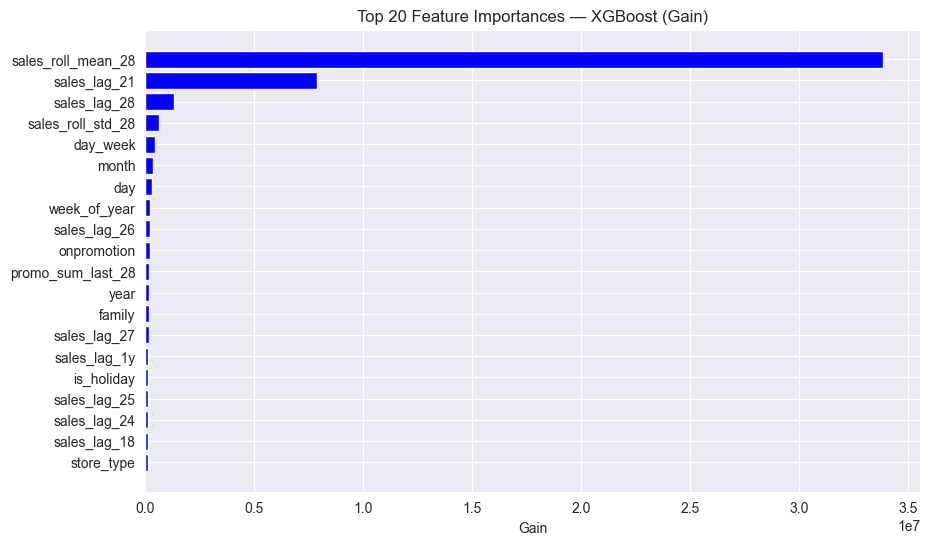

In [116]:
# Получаем важность признаков по gain
gain_importances = xgb.get_booster().get_score(importance_type='gain')

# Переводим в DataFrame
fi_df = pd.DataFrame({
    'feature': list(gain_importances.keys()),
    'importance': list(gain_importances.values())
}).sort_values(by='importance', ascending=False)

# Топ-20 признаков
fi_df_top20 = fi_df.head(20)
print(fi_df_top20)

# Визуализация
plt.figure(figsize=(10, 6))
plt.barh(fi_df_top20['feature'][::-1], fi_df_top20['importance'][::-1], color='blue')
plt.xlabel('Gain')
plt.title('Top 20 Feature Importances — XGBoost (Gain)')
plt.show()

### HistGradientBoostingRegressor

In [117]:
# Параметры модели
hgb = HistGradientBoostingRegressor(
    max_depth=10,
    learning_rate=0.05,
    max_iter=300,
    random_state=42
)

# Обучение
hgb.fit(X_train, y_train)

# Предсказания на валидации
y_val_pred_hgb = hgb.predict(X_val)

# RMSLE
rmsle_hgb = rmsle(y_val, y_val_pred_hgb)
print(f'RMSLE HGB: {rmsle_hgb:.5f}')

RMSLE HGB: 0.47654


RMSLE HGB: 0.47654

### CatBoost

In [118]:
# Параметры модели
cat = CatBoostRegressor(
    iterations=200,
    depth=8,
    learning_rate=0.05,
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)

# Обучение
cat.fit(X_train, y_train)

# Предсказания на валидации
y_val_pred_cat = cat.predict(X_val)

# RMSLE
rmsle_cat = rmsle(y_val, y_val_pred_cat)
print(f'RMSLE CatBoost: {rmsle_cat:.5f}')

RMSLE CatBoost: 0.51605


RMSLE CatBoost: 0.51605

### LightGBM

In [119]:
# Параметры модели
lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Обучение
lgbm.fit(X_train, y_train)

# Предсказания на валидации
y_val_pred_lgbm = lgbm.predict(X_val)

# RMSLE
rmsle_lgbm = rmsle(y_val, y_val_pred_lgbm)
print(f'RMSLE LGBM: {rmsle_lgbm:.5f}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.219604 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7886
[LightGBM] [Info] Number of data points in the train set: 2454682, number of used features: 49
[LightGBM] [Info] Start training from score 46.954628
RMSLE LGBM: 0.46532


RMSLE LGBM: 0.46532

               feature  importance
9             day_week        2771
33   sales_roll_std_28        2371
1               family        2198
32  sales_roll_mean_28        2145
8                  day        1600
0            store_nbr        1519
10        week_of_year        1470
7                month         930
22        sales_lag_21         834
2          onpromotion         818
29        sales_lag_28         776
15           oil_price         760
34        sales_lag_1y         754
14             cluster         689
48    oil_price_lag_28         625
45     oil_price_lag_7         616
44     oil_price_lag_1         585
12               state         536
13          store_type         496
11                city         468


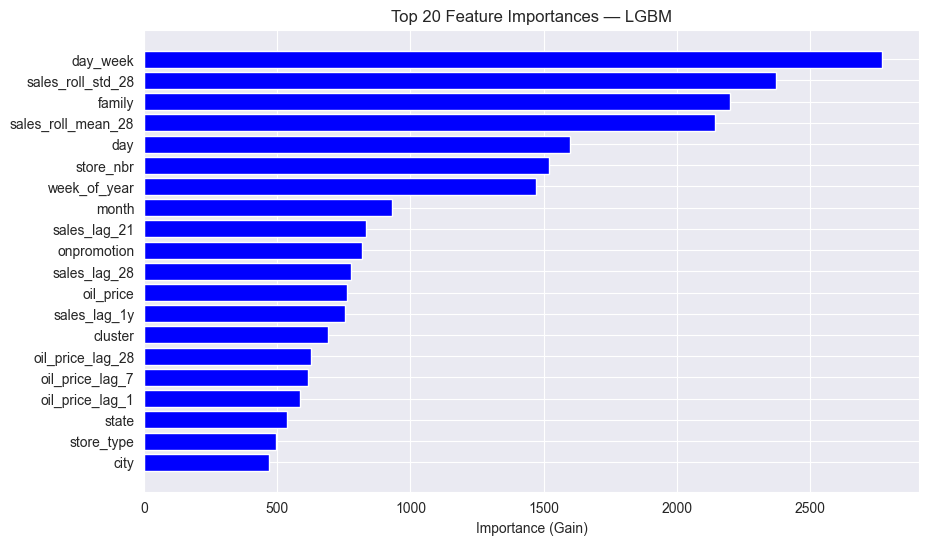

In [120]:
# 1. Получаем важности по gain
feature_importances = lgbm.feature_importances_  # по умолчанию gain
feature_names = X_train.columns

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)

# 2. Топ-20 признаков
fi_df_top20 = fi_df.head(20)
print(fi_df_top20)

# 3. Визуализация
plt.figure(figsize=(10, 6))
plt.barh(fi_df_top20['feature'][::-1], fi_df_top20['importance'][::-1], color='blue')
plt.xlabel('Importance (Gain)')
plt.title('Top 20 Feature Importances — LGBM')
plt.show()

### Результаты точности на валидационной выборки

| Модель                        | RMSLE (Validation) |
| ----------------------------- | ------------------ |
| **XGBoost**                   | **0.45406**        |
| LightGBM                      | 0.46532            |
| HistGradientBoostingRegressor | 0.47654            |
| Random Forest Regressor       | 0.47233            |
| CatBoost                      | 0.51605            |


## GridSearch

### GridSearch для XGBoost

In [121]:
# param_grid = {
#     'n_estimators': [200, 300],
#     'max_depth': [4, 6, 8, 10],
#     'learning_rate': [0.05, 0.1, 0, 2],
#     'subsample': [0.8, 1],
#     'colsample_bytree': [0.8]
# }
#
# # Модель
# xgb = XGBRegressor(
#     objective='reg:squarederror',
#     random_state=42,
#     n_jobs=-1
# )
#
# # TimeSeriesSplit для временных рядов
# tscv = TimeSeriesSplit(n_splits=3)
#
# # GridSearchCV
# grid = GridSearchCV(
#     estimator=xgb,
#     param_grid=param_grid,
#     scoring=make_scorer(rmsle, greater_is_better=False),
#     cv=tscv,
#     verbose=2
# )

In [122]:
# grid.fit(X_train, y_train)
#
# print("Лучшие параметры:", grid.best_params_)
# print("RMSLE на train CV:", -grid.best_score_)

Лучшие параметры: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.8}

RMSLE на train CV: 0.5454017209844199

#### Проверка на валидации

In [123]:
# best_model = grid.best_estimator_
# y_val_pred = best_model.predict(X_val)
# print("RMSLE на validation:", rmsle(y_val, y_val_pred))

RMSLE на validation: 0.4501433982552072

### GridSearch для LightGBM

In [124]:
# param_grid_lgb = {
#     'n_estimators': [200, 300],
#     'max_depth': [4, 6, 8, 10],
#     'learning_rate': [0.05, 0.1, 0, 2],
#     'subsample': [0.8, 1],
#     'colsample_bytree': [0.8]
# }
#
# # Модель
# lgb = LGBMRegressor(
#     objective='regression',
#     random_state=42,
#     n_jobs=-1
# )
#
# # TimeSeriesSplit
# tscv = TimeSeriesSplit(n_splits=3)
#
# # GridSearchCV
# grid_lgb = GridSearchCV(
#     estimator=lgb,
#     param_grid=param_grid_lgb,
#     scoring=make_scorer(rmsle, greater_is_better=False),
#     cv=tscv,
#     verbose=2
# )

In [125]:
# grid_lgb.fit(X_train, y_train)
#
# print("Лучшие параметры LGBM:", grid_lgb.best_params_)
# print("RMSLE на train CV:", -grid_lgb.best_score_)

Лучшие параметры LGBM: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.8}

RMSLE на train CV: 0.5926606340551516

#### Проверка на валидации

In [126]:
# best_lgb = grid_lgb.best_estimator_
# y_val_pred_lgb = best_lgb.predict(X_val)
# print("RMSLE на validation LGBM:", rmsle(y_val, y_val_pred_lgb))

RMSLE на validation LGBM: 0.4755059355273676

## Обучение лучших моделей

In [127]:
train_df.date.min(), train_df.date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [128]:
test_df.isna().sum()

store_nbr                0
family                   0
onpromotion              0
id                       0
is_payday                0
is_payday_next           0
post_earthquake          0
year                     0
month                    0
day                      0
day_week                 0
week_of_year             0
city                     0
state                    0
store_type               0
cluster                  0
oil_price                0
is_holiday               0
sales_lag_16             0
sales_lag_17             0
sales_lag_18             0
sales_lag_19             0
sales_lag_20             0
sales_lag_21             0
sales_lag_22             0
sales_lag_23             0
sales_lag_24             0
sales_lag_25             0
sales_lag_26             0
sales_lag_27             0
sales_lag_28             0
sales_lag_29             0
sales_lag_30             0
sales_roll_mean_28       0
sales_roll_std_28        0
sales_lag_1y          5486
onpromo_lag_1            0
o

In [129]:
lag_cols = [c for c in test_df.columns if 'lag' in c
            or 'roll' in c
            or 'promo_sum' in c
            or 'diff' in c
            or 'pctchg' in c]

test_df[lag_cols] = test_df[lag_cols].fillna(0)


In [130]:
test_df.isna().sum()

store_nbr             0
family                0
onpromotion           0
id                    0
is_payday             0
is_payday_next        0
post_earthquake       0
year                  0
month                 0
day                   0
day_week              0
week_of_year          0
city                  0
state                 0
store_type            0
cluster               0
oil_price             0
is_holiday            0
sales_lag_16          0
sales_lag_17          0
sales_lag_18          0
sales_lag_19          0
sales_lag_20          0
sales_lag_21          0
sales_lag_22          0
sales_lag_23          0
sales_lag_24          0
sales_lag_25          0
sales_lag_26          0
sales_lag_27          0
sales_lag_28          0
sales_lag_29          0
sales_lag_30          0
sales_roll_mean_28    0
sales_roll_std_28     0
sales_lag_1y          0
onpromo_lag_1         0
onpromo_lag_7         0
onpromo_lag_14        0
onpromo_lag_16        0
onpromo_lag_28        0
promo_sum_last_7

In [131]:
target = 'sales'
features = [c for c in train_df.columns if c not in ['sales', 'date']]

# Создаём X и y для train, X для test
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]

In [132]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)

X_train: (2475755, 49)
y_train: (2475755,)
X_test: (28512, 49)


### XGBoost

**XGBoost**

Лучшие параметры: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.8}

In [133]:
final_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Обучение на всей тренировочной выборке
final_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [134]:
y_pred_train = final_xgb.predict(X_train)

# На всякий случай обрезаем отрицательные предсказания
y_pred_train = np.maximum(y_pred_train, 0)

# Вычисляем RMSLE
rmsle_train = np.sqrt(mean_squared_log_error(y_train, y_pred_train))
print("RMSLE на тренировочной выборке:", rmsle_train)

RMSLE на тренировочной выборке: 0.5144265208665736


#### Предсказания

In [135]:
# Предсказания
test_preds = final_xgb.predict(X_test)

# Обрезаем отрицательные значения
test_preds = np.maximum(0, test_preds)

# Проверка размеров
print("Размер предсказаний:", len(test_preds))
print("Первые 5 предсказаний:", test_preds[:5])

Размер предсказаний: 28512
Первые 5 предсказаний: [5.0329986 4.9370217 5.271942  5.883643  3.6033363]


In [136]:
submission = test_df[['id']].copy()
submission['sales'] = test_preds
submission['id'] = submission['id'].astype(int)

submission = submission.sort_values('id').reset_index(drop=True)

submission.head()

,id,sales
0,3000888,5.032999
1,3000889,0.303568
2,3000890,5.779960
3,3000891,244.693451
4,3000892,0.333711


In [137]:
submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      28512 non-null  int64  
 1   sales   28512 non-null  float32
dtypes: float32(1), int64(1)
memory usage: 334.3 KB


In [138]:
submission.to_csv('Mostov_answer_xgb.csv', index=False)

### LightGBM

Лучшие параметры LGBM: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.8}


In [139]:
final_lgb = LGBMRegressor(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='regression',
    random_state=42,
    n_jobs=-1
)

# Обучение на всей тренировочной выборке
final_lgb.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.201550 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7853
[LightGBM] [Info] Number of data points in the train set: 2475755, number of used features: 49
[LightGBM] [Info] Start training from score 47.056062


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


#### Предсказания

In [140]:
# Предсказания
test_preds_lgb = final_lgb.predict(X_test)

# Обрезаем отрицательные значения
test_preds_lgb = np.maximum(0, test_preds_lgb)

In [141]:
submission_lgb = test_df[['id']].copy()
submission_lgb['sales'] = test_preds_lgb

# Приводим id к целому числу
submission_lgb['id'] = submission_lgb['id'].astype(int)

# Сортировка по id
submission_lgb = submission_lgb.sort_values('id').reset_index(drop=True)


submission_lgb.head()

,id,sales
0,3000888,5.178633
1,3000889,0.574774
2,3000890,7.499825
3,3000891,380.363916
4,3000892,0.574774


In [142]:
# Сохраняем CSV
submission_lgb.to_csv('Mostov_answer_lgb.csv', index=False)